In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xgboost as xgb
import gseapy as gp
from scipy import stats
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
import matplotlib.patches as mptaches

In [2]:
# Reading the file into a dataframe
file = "43587_2024_572_MOESM11_ESM.xlsx"
meta_file = "43587_2024_572_MOESM4_ESM.xlsx"
pathway_file = "43587_2024_572_MOESM14_ESM(1).xlsx"

sheets = pd.read_excel(file, sheet_name=None)
meta_info = pd.read_excel(meta_file,sheet_name='Fig 1a')
pathway_info = pd.read_excel(pathway_file, sheet_name='Extended Data Fig 4a')

In [3]:
#Fig 1b, 1g-h, and 1m are the important ones, highlighting transcriptomics, proteomics, and metaboliomics
sheets.keys()

dict_keys(['Extended Data Fig 1b', 'Extended Data Fig 1d', 'Extended Data Fig 1g-h', 'Extended Data Fig 1k', 'Extended Data Fig 1m'])

In [4]:
# Segmenting what each part we want to analyze into their own dataframes
# All tables are similar, with having first two rows be nothing then the table
# So start reading at the 3 row
transcript = sheets['Extended Data Fig 1b'][1:]

metabolimics = sheets['Extended Data Fig 1m'][1:]

In [5]:
# This cleans the transcript table, setting the first column
# to be the index and then removing the first two blank rows
if transcript.iloc[0,0] == 'Genes names':
   
    #Take the first two rows, set the index to the first column
    transcript.columns = transcript.iloc[0]
    transcript = transcript.set_index(transcript.columns[0])
    transcript = transcript[1:]

    # Make sure the table is all numbers and not strings
    transcript = transcript.drop(columns=['Average'])

    transcript = transcript.apply(pd.to_numeric, errors='coerce')
else:
    print("Transcript Table Already Clean")

transcript


1,2-16-A,2-16-D,2-16-R,2-16-T,2-18-A,2-18-D,2-18-R,2-18-T,2-20-A,2-20-D,...,3-4-R,3-4-T,3-7-A,3-7-D,3-7-R,3-7-T,F-A,F-D,F-R,F-T
Genes names,,,,,,,,,,,,,,,,,,,,,
A1CF,2.919161,0.818505,0.898932,7.047423,8.516385,1.921141,3.702799,2.533168,6.164409,6.629778,...,0.031626,8.102981,0.338646,2.949231,2.626652,3.694100,5.807363,0.957221,0.424012,1.858392
A4GALT,20.191836,21.931819,19.829763,16.381777,18.666224,26.084845,31.663439,22.288708,19.326626,15.933239,...,23.929200,15.115398,21.043088,23.388962,15.778318,17.869061,14.801394,21.341784,27.510828,22.230170
AAAS,21.977486,17.177612,12.013416,20.894892,26.191219,22.697576,22.329424,20.723074,24.269922,22.635015,...,20.788020,30.438648,19.142039,27.264017,31.582314,23.415146,27.886452,22.841766,30.473398,17.435181
AACS,16.589739,12.973910,7.937718,19.567291,24.184907,17.272147,20.031992,16.394612,19.350073,13.821409,...,7.575711,40.680395,12.176946,12.914070,29.562497,22.802305,16.280183,6.390602,8.067762,7.150808
AADAT,1.670095,1.248359,2.312795,3.243973,2.607915,2.318798,1.976999,2.235828,3.133924,3.300966,...,5.331179,5.626459,2.514506,2.063896,4.363030,2.913697,1.990690,3.100486,4.339637,2.260258
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDC,9.879239,7.906566,7.604562,10.523804,9.089731,8.117340,8.722162,6.648719,6.893890,10.009964,...,9.568055,10.745696,7.950098,8.492898,12.081805,8.365174,8.429867,9.090944,13.037477,7.204315
ZYG11B,7.690692,4.315668,5.682372,16.736190,14.715278,7.107900,9.579220,7.631582,12.019502,13.859089,...,4.115984,12.774833,7.995443,4.920945,6.771033,8.785712,8.484677,2.185604,0.742861,3.171297
ZYX,72.405138,92.613006,152.178976,81.950152,56.346047,129.186510,101.603799,66.961835,50.221696,56.133102,...,163.483097,52.567067,138.916329,58.602234,95.339998,48.791020,41.937338,95.694881,94.905449,131.383608


In [57]:
proteins = sheets['Extended Data Fig 1g-h'][1:]
#Take the first two rows, set the index to the first column

proteins.columns = proteins.iloc[0]
proteins = proteins[1:]
#uniprot_to_gene = dict(zip(proteins['Uniprot ID'], proteins['Gene names']))
proteins = proteins.set_index(proteins.columns[1])
#proteins = proteins[1:]


# Make sure the table is all numbers and not strings
proteins = proteins.drop(columns=['Uniprot ID'])

proteins = proteins.apply(pd.to_numeric, errors='coerce')

proteins = proteins.dropna(how='any')


proteins

1,2-29-A,2-7-A,2-8-A,2-16-A,2-18-A,2-20-A,2-23-A,2-29-T,2-8-T,2-16-T,...,2-30-R,3-25-R,2-7-T,3-19-A,3-7-A,2-29-D,3-15-D,3-15-T,3-18-D,3-19-D
Gene names,,,,,,,,,,,,,,,,,,,,,
GSTP1,0.947451,1.160542,1.084707,0.985390,0.875839,0.837299,0.794411,0.955362,1.060946,0.846684,...,0.789786,0.651540,0.898998,0.838027,1.145696,0.795706,1.051965,0.932046,0.773629,0.833231
GAPDH,0.927883,1.284003,0.964951,1.118563,0.971331,0.910677,1.045518,1.035092,1.224453,1.081631,...,1.097350,3.702514,1.126977,1.174646,1.550338,1.595955,1.183228,1.131521,1.202691,0.945105
OAS1,0.883592,0.820048,1.583599,0.580530,1.093860,1.372942,1.461154,0.722997,1.395069,0.790776,...,0.711842,1.323365,0.817531,0.867034,0.420517,0.086007,0.980983,1.131720,0.948612,1.103268
CES1,1.468547,1.506702,1.640234,0.943155,0.911634,1.487612,0.936032,1.209600,1.576961,1.069153,...,0.485954,0.504485,1.228234,0.865431,0.525230,0.329712,1.797434,2.379647,0.606275,1.377644
PDCD6,1.683050,1.373192,1.006688,1.011671,1.072028,0.918124,1.080083,1.704611,1.120459,1.220846,...,1.153488,0.917397,1.153763,1.480637,0.990853,1.533412,1.169462,1.020476,1.132429,1.524681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TANGO2,0.858542,1.183900,0.999958,0.937866,0.992129,0.859369,0.866797,0.879621,1.160718,0.963463,...,0.992491,0.737889,1.104054,0.913428,0.837250,0.883063,0.855609,0.756773,0.716689,0.922293
TAMM41,0.936670,0.865762,1.516996,1.040369,1.324212,1.372732,1.106263,0.887945,1.073248,0.856725,...,0.911933,0.976623,1.034377,0.805510,0.759976,0.496169,1.062141,0.991801,0.587168,1.089838
IGHG1,0.856162,1.499562,1.089590,2.065222,0.855087,0.655113,0.718587,0.947170,1.053603,1.524258,...,0.452966,0.388537,1.098382,2.912636,1.771690,1.317356,1.219071,1.232026,1.738107,2.926823


In [58]:
uniprot_to_gene

{'A0A023JCR5': 'GSTP1',
 'A0A0A7KUP9': 'GAPDH',
 'A0A0K0N4X4': 'OAS1',
 'A0A171P0Z2': 'CES1',
 'A2V9Y3': 'PDCD6',
 'A2V9Z6': 'ADH1B',
 'A5HLX2': 'PSMB9',
 'B3Y602': 'DES',
 'C0SJM5': 'GSTO1',
 'C0SJM7': 'MGST1',
 'C1KJW8': 'B2M',
 'E5FGN6': 'NHEJ1',
 'G7NT94': 'RER1',
 'G7NTA4': 'ARHGEF16',
 'G7NTA9': 'LRRC47',
 'G7NTB4': 'ACOT7',
 'G7NTC9': 'PARK7',
 'G7NTD9': 'H6PD',
 'G7NTE4': 'RBBP4',
 'G7NTE7': 'YARS',
 'G7NTF3': 'AK2',
 'G7NTH2': 'PSMB2',
 'G7NTH6': 'LOC102146235',
 'G7NTI0': 'ADPRHL2',
 'G7NTI2': 'TRAPPC3',
 'G7NTI7': 'MRPS15',
 'G7NTK9': 'BCL10',
 'G7NTL0': 'DDAH1',
 'G7NTL5': 'CLCA1',
 'G7NTL6': 'CLCA4',
 'G7NTL9': 'SH3GLB1',
 'G7NTM2': 'PKN2',
 'G7NTM4': 'GBP6',
 'G7NTP5': 'GCLM',
 'G7NTQ8': 'ACP6',
 'G7NTR8': 'BOLA1',
 'G7NTS3': 'VPS45',
 'G7NTT0': 'PRPF3',
 'G7NTT2': 'TARS2',
 'G7NTT3': 'ECM1',
 'G7NTU1': 'THEM4',
 'G7NTU2': 'S100A10',
 'G7NTU4': 'S100A11',
 'G7NTV2': 'PARP1',
 'G7NTV5': 'ACBD3',
 'G7NTV9': 'LBR',
 'G7NTW2': 'WDR26',
 'G7NTX5': 'BROX',
 'G7NTX7': 'MIA3',
 '

In [7]:
pathway = pathway_info
pathway = pathway.iloc[:, 21:]  # 21 = column V (0-indexed)
pathway= pathway[2:]

pathway.columns = pathway.iloc[0]
pathway = pathway.drop(index=2)
pathway.reset_index()

pathway['Genes'] = pathway['Genes'].str.split(', ')

# Explode so each gene has its own row
pathway_exploded = pathway.explode('Genes').reset_index(drop=True)

pathway_exploded[['Sex', 'Region']] = pathway_exploded['Group'].str.extract(r'(\w+)\((\w+)\)')

# Drop original combined column if you want
pathway_exploded = pathway_exploded.drop(columns='Group')

pathway_exploded


2,Pathway ID,Pathway name,Displayed in Extended Data Fig. 4a,Count,p value,Fold Enrichment,FDR,Genes,Sex,Region
0,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,INO80C,male,Proximal
1,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,SMARCAL1,male,Proximal
2,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,KDM3B,male,Proximal
3,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,HDAC3,male,Proximal
4,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,INO80D,male,Proximal
...,...,...,...,...,...,...,...,...,...,...
16664,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Group by metadata + gene and list pathways
gene_meta2pathway = pathway_exploded.groupby(['Genes', 'Region', 'Sex'])['Pathway name'].apply(list).to_dict()

# Example lookup
gene_meta2pathway.get(('BRCA1', 'Distal', 'Female'))
# Output: ['DNA repair']


In [9]:
# Copy of the table so I dont have to wait after messing up
meta = meta_info.copy()
all_meta = meta_info.copy()

In [10]:
# Very slight cleaning before being able to create the mapping desired
meta = meta[1:]
meta.columns = meta.iloc[0]
meta = meta[meta['Transcriptome'] == 1]

all_meta = all_meta[1:]
all_meta.columns = all_meta.iloc[0]
all_meta = all_meta[1:]

In [11]:
all_meta

1,NaN,Macaca fascicularis ID,Macaca fascicularis Sample ID,Proteome Batch,Age,Location,Region,Gender,Transcriptome,Proteome,Phosphoproteome,Metabolome
2,NaN,A04,2-22-A,5,Middle age,Ascending colon,Proximal,Female,1,1,1,1
3,NaN,A04,2-22-D,7,Middle age,Descending colon,Distal,Female,1,1,1,1
4,NaN,A04,2-22-R,8,Middle age,Rectum,Distal,Female,1,1,1,1
5,NaN,A04,2-22-T,6,Middle age,Transverse colon,Proximal,Female,1,1,1,1
6,NaN,A06,2-25-A,5,Middle age,Ascending colon,Proximal,Female,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
101,NaN,A13,2-9-T,NaN,Young,Transverse colon,Distal,Male,NaN,NaN,1,1
102,NaN,A18,3-1-A,NaN,Young,Ascending colon,Proximal,Male,NaN,NaN,1,1
103,NaN,A18,3-1-D,NaN,Young,Descending colon,Distal,Male,NaN,NaN,1,1
104,NaN,A18,3-1-R,NaN,Young,Rectum,Distal,Male,NaN,NaN,1,1


In [12]:
sample_to_info = meta.set_index('Macaca fascicularis Sample ID')[['Age', 'Gender','Region','Location']].to_dict(orient='index')

metadata = pd.DataFrame.from_dict(sample_to_info, orient='index')

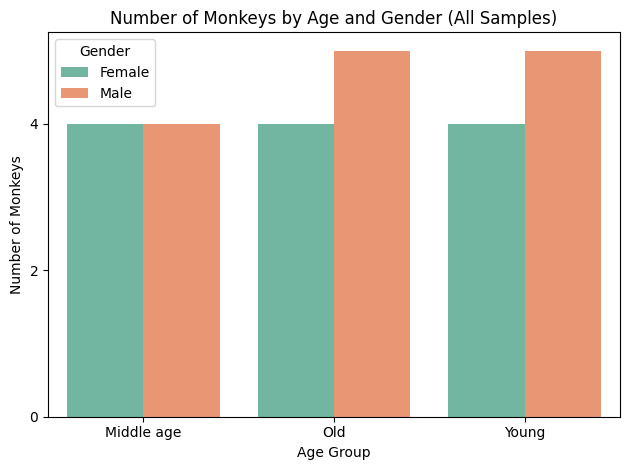

In [13]:

import matplotlib.ticker as mticker

sample_counts = all_meta.groupby(['Age', 'Gender']).size().reset_index(name='Count')

sample_counts['Count'] = sample_counts['Count'] / 4

ax = sns.barplot(data=sample_counts, x='Age', y='Count', hue='Gender', palette='Set2')

# Adjust y-axis to go up by 2s
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))

plt.title('Number of Monkeys by Age and Gender (All Samples)')
plt.ylabel('Number of Monkeys')
plt.xlabel('Age Group')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


In [14]:
sample_counts

,Age,Gender,Count
0,Middle age,Female,4.0
1,Middle age,Male,4.0
2,Old,Female,4.0
3,Old,Male,5.0
4,Young,Female,4.0
5,Young,Male,5.0


In [15]:
meta

1,NaN,Macaca fascicularis ID,Macaca fascicularis Sample ID,Proteome Batch,Age,Location,Region,Gender,Transcriptome,Proteome,Phosphoproteome,Metabolome
2,NaN,A04,2-22-A,5,Middle age,Ascending colon,Proximal,Female,1,1,1,1
3,NaN,A04,2-22-D,7,Middle age,Descending colon,Distal,Female,1,1,1,1
4,NaN,A04,2-22-R,8,Middle age,Rectum,Distal,Female,1,1,1,1
5,NaN,A04,2-22-T,6,Middle age,Transverse colon,Proximal,Female,1,1,1,1
6,NaN,A06,2-25-A,5,Middle age,Ascending colon,Proximal,Female,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
93,NaN,A11,2-7-T,2,Young,Transverse colon,Proximal,Male,1,1,NaN,1
94,NaN,A12,2-8-A,1,Young,Ascending colon,Proximal,Male,1,1,NaN,1
95,NaN,A12,2-8-D,3,Young,Descending colon,Distal,Male,1,1,1,1
96,NaN,A12,2-8-R,4,Young,Rectum,Distal,Male,1,1,1,1


In [16]:
# Mapping of sample to meta information as needed
for k, v in list(sample_to_info.items()):
    print(k, '→', v)

2-22-A → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Proximal', 'Location': 'Ascending colon'}
2-22-D → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Descending colon'}
2-22-R → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Rectum'}
2-22-T → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Proximal', 'Location': 'Transverse colon'}
2-25-A → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Proximal', 'Location': 'Ascending colon'}
2-25-D → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Descending colon'}
2-25-R → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Rectum'}
2-25-T → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Transverse colon'}
3-28-A → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Proximal', 'Location': 'Ascending colon'}
3-28-D → {'Age': 'Middle age', 'Gender': 'Female', 'Region': 'Distal', 'Location': 'Desc

In [17]:

transcript.iloc[0]

1
2-16-A    2.919161
2-16-D    0.818505
2-16-R    0.898932
2-16-T    7.047423
2-18-A    8.516385
            ...   
3-7-T     3.694100
F-A       5.807363
F-D       0.957221
F-R       0.424012
F-T       1.858392
Name: A1CF, Length: 82, dtype: float64

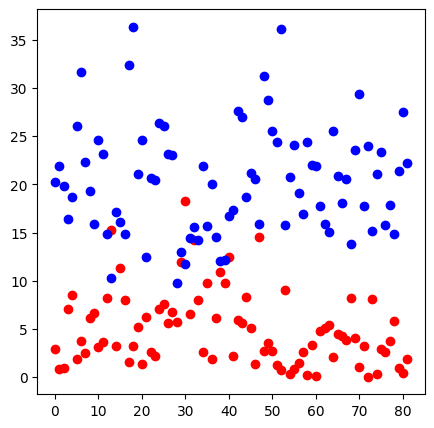

In [18]:
# I want to scatter plot 2 random genes with all the samples
plt.figure(figsize=(5,5))

# Plotting Gene 1 in Red
plt.scatter(range(len(transcript.columns)), transcript.iloc[0], color='red', label='Gene 1')

# Plot Gene 2 in blue
plt.scatter(range(len(transcript.columns)), transcript.iloc[1], color='blue', label='Gene 2')

plt.show()

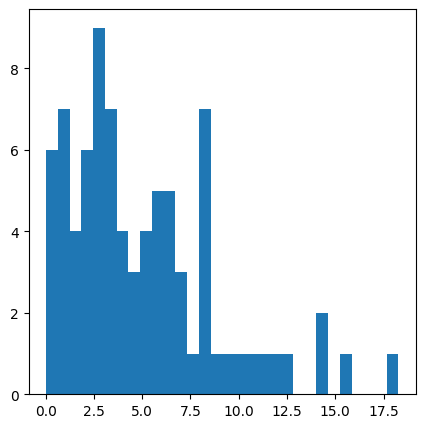

In [19]:
plt.figure(figsize=(5,5))
plt.hist(transcript.iloc[0],30)
plt.show()

In [20]:
# Let us take the log transform of the data 
# in order to better normalize and treat the data
from sklearn.discriminant_analysis import StandardScaler


transcript_log = np.log2(transcript + 1)

scaler = StandardScaler()
norm_df = pd.DataFrame(
    scaler.fit_transform(transcript_log),
    index=transcript_log.index,
    columns=transcript_log.columns
)
transcript_scaled = norm_df

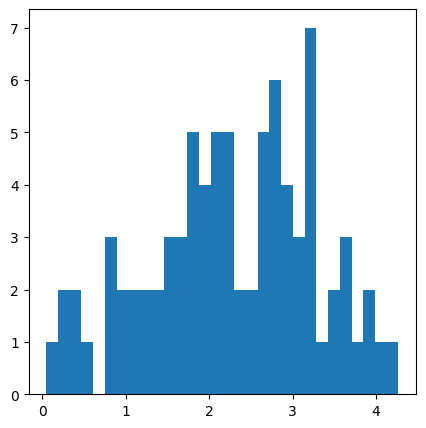

In [21]:
plt.figure(figsize=(5,5))
plt.hist(transcript_log.iloc[0],30)
plt.show()

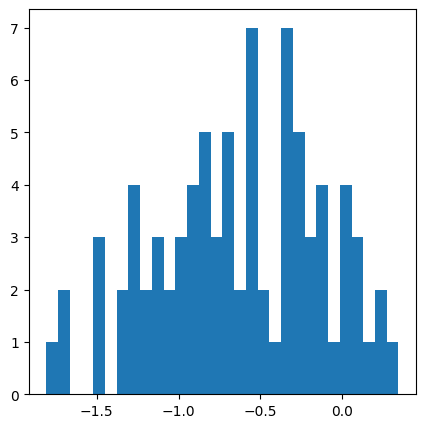

In [22]:
plt.figure(figsize=(5,5))
plt.hist(transcript_scaled.iloc[0],30)
plt.show()


In [23]:
# Want to create different dataframes which categorizes between
# Male and Female
# young, middle, and old
# and then the 4 zones of intestines they took tissue from
male_samples = [s for s, info in sample_to_info.items() if info['Gender'] == 'Male']
female_samples = [s for s, info in sample_to_info.items() if info['Gender'] == 'Female']

young_samples = [samples for samples, info in sample_to_info.items() if info['Age'] == 'Young']
middle_samples = [samples for samples, info in sample_to_info.items() if info['Age'] == 'Middle age']
old_samples = [samples for samples, info in sample_to_info.items() if info['Age'] == 'Old']

proximal_samples = [samples for samples, info in sample_to_info.items() if info['Region'] == 'Proximal']
distal_samples = [samples for samples, info in sample_to_info.items() if info['Region'] == 'Distal']

young_proximal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Young' and info['Region'] == 'Proximal'
]

middle_proximal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Middle age' and info['Region'] == 'Proximal'
]

old_proximal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Old' and info['Region'] == 'Proximal'
]

young_distal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Young' and info['Region'] == 'Distal'
]

middle_distal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Middle age' and info['Region'] == 'Distal'
]

old_distal_samples = [
    s for s, info in sample_to_info.items()
    if info['Age'] == 'Old' and info['Region'] == 'Distal'
]

# Making the subsets of the dataframe of analysis
transcript_male = transcript_log[male_samples]
transcript_female = transcript_log[female_samples]

transcript_young = transcript_log[young_samples]
transcript_middle = transcript_log[middle_samples]
transcript_old = transcript_log[old_samples]

transcript_proximal = transcript_log[proximal_samples]
transcript_distal = transcript_log[distal_samples]

transcript_young_proximal = transcript_log[young_proximal_samples]
transcript_middle_proximal = transcript_log[middle_proximal_samples]
transcript_old_proximal = transcript_log[old_proximal_samples]


transcript_young_distal = transcript_log[young_distal_samples]
transcript_middle_distal = transcript_log[middle_distal_samples]
transcript_old_distal = transcript_log[old_distal_samples]

In [24]:
# Now we want to compare and see which gene names have
# The biggest variance between genders
male_mean = transcript_male.mean(axis=1)
male_var = transcript_male.var(axis=1)

female_mean = transcript_female.mean(axis=1)
female_var = transcript_female.var(axis=1)

young_mean = transcript_young.mean(axis=1)
young_var = transcript_young.var(axis=1)

middle_mean = transcript_middle.mean(axis=1)
middle_var = transcript_middle.var(axis=1)

old_mean = transcript_old.mean(axis=1)
old_var = transcript_old.var(axis=1)

proximal_mean = transcript_proximal.mean(axis=1)
proximal_var = transcript_proximal.var(axis=1)

distal_mean = transcript_distal.mean(axis=1)
distal_var = transcript_distal.var(axis=1)

old_proximal_mean = transcript_old_proximal.mean(axis=1)
old_proximal_var = transcript_old_proximal.var(axis=1)

middle_proximal_mean = transcript_middle_proximal.mean(axis=1)
middle_proximal_var = transcript_middle_proximal.var(axis=1)

young_proximal_mean = transcript_young_proximal.mean(axis=1)
young_proximal_var = transcript_young_proximal.var(axis=1)

old_distal_mean = transcript_old_distal.mean(axis=1)
old_distal_var = transcript_old_distal.var(axis=1)

middle_distal_mean = transcript_middle_distal.mean(axis=1)
middle_distal_var = transcript_middle_distal.var(axis=1)

young_distal_mean = transcript_young_distal.mean(axis=1)
young_distal_var = transcript_young_distal.var(axis=1)

In [25]:

# Combine the three group means into a single DataFrame
age_means_df = pd.DataFrame({
    'Young': young_mean,
    'Middle': middle_mean,
    'Old': old_mean
})

# Calculate the variance across the three age means for each gene
age_means_df['AgeGroup_Variance'] = age_means_df.var(axis=1)

# Sort by highest variance to see which genes differ most by age
age_means_df_sorted = age_means_df.sort_values('AgeGroup_Variance', ascending=False)

# Show the top 10 genes with greatest variance across ages
top_variance_genes = age_means_df_sorted.head(10)

print(top_variance_genes)


                 Young    Middle       Old  AgeGroup_Variance
Genes names                                                  
LOC102120471  1.743812  5.497087  3.549754           3.523434
LOC102134021  0.032285  0.000000  2.201592           1.592324
LEP           1.450325  3.266475  3.475162           1.240320
HMGCS2        5.966678  5.417424  4.008703           1.019974
CD177         6.063504  4.385456  6.148798           0.988749
LOC102135255  2.563598  0.896924  0.865395           0.943781
PCK1          6.706519  6.088010  4.873301           0.869793
ABO           4.001498  3.604797  2.317511           0.775048
CLCA4         7.657886  7.113240  5.955938           0.755435
CHIT1         1.912263  2.590485  3.633995           0.752210


In [26]:
import pandas as pd

# === COMBINE OVERALL AGE MEANS ===
age_means_df = pd.DataFrame({
    'Young': young_mean,
    'Middle': middle_mean,
    'Old': old_mean
})
age_means_df['Age_Variance'] = age_means_df.var(axis=1)

# === COMBINE PROXIMAL AGE MEANS ===
proximal_means_df = pd.DataFrame({
    'Young_Proximal': young_proximal_mean,
    'Middle_Proximal': middle_proximal_mean,
    'Old_Proximal': old_proximal_mean
})
proximal_means_df['Proximal_Variance'] = proximal_means_df.var(axis=1)

# === COMBINE DISTAL AGE MEANS ===
distal_means_df = pd.DataFrame({
    'Young_Distal': young_distal_mean,
    'Middle_Distal': middle_distal_mean,
    'Old_Distal': old_distal_mean
})
distal_means_df['Distal_Variance'] = distal_means_df.var(axis=1)

# === MERGE EVERYTHING INTO ONE BIG TABLE ===
combined_df = pd.concat([age_means_df, proximal_means_df, distal_means_df], axis=1)

# === SORTED TABLES ===
combined_df_sorted_age = combined_df.sort_values('Age_Variance', ascending=False)
combined_df_sorted_prox = combined_df.sort_values('Proximal_Variance', ascending=False)
combined_df_sorted_dist = combined_df.sort_values('Distal_Variance', ascending=False)

# === TOP 10 MOST VARIABLE GENES IN EACH CATEGORY ===
top10_age = combined_df_sorted_age.head(10)
top10_prox = combined_df_sorted_prox.head(10)
top10_dist = combined_df_sorted_dist.head(10)

# === PRINT RESULTS ===
print("\n Top 10 Most Variable Genes Across Ages:")
print(top10_age[['Young', 'Middle', 'Old', 'Age_Variance']])

print("\n Top 10 Most Variable Genes in Proximal Zone:")
print(top10_prox[['Young_Proximal', 'Middle_Proximal', 'Old_Proximal', 'Proximal_Variance']])






 Top 10 Most Variable Genes Across Ages:
                 Young    Middle       Old  Age_Variance
Genes names                                             
LOC102120471  1.743812  5.497087  3.549754      3.523434
LOC102134021  0.032285  0.000000  2.201592      1.592324
LEP           1.450325  3.266475  3.475162      1.240320
HMGCS2        5.966678  5.417424  4.008703      1.019974
CD177         6.063504  4.385456  6.148798      0.988749
LOC102135255  2.563598  0.896924  0.865395      0.943781
PCK1          6.706519  6.088010  4.873301      0.869793
ABO           4.001498  3.604797  2.317511      0.775048
CLCA4         7.657886  7.113240  5.955938      0.755435
CHIT1         1.912263  2.590485  3.633995      0.752210

 Top 10 Most Variable Genes in Proximal Zone:
              Young_Proximal  Middle_Proximal  Old_Proximal  Proximal_Variance
Genes names                                                                   
SLC14A2             4.651874         2.880499      1.063662          

In [27]:
print("\n Top 10 Most Variable Genes in Distal Zone:")
print(top10_dist[['Young_Distal', 'Middle_Distal', 'Old_Distal', 'Distal_Variance']])


 Top 10 Most Variable Genes in Distal Zone:
              Young_Distal  Middle_Distal  Old_Distal  Distal_Variance
Genes names                                                           
LOC102120471      1.666524       5.758222    3.486302         4.202534
LEP               1.388503       3.131390    3.494379         1.267355
CD177             6.290964       4.716278    6.735828         1.126020
LOC102135255      2.829764       1.085595    0.950432         1.098713
LOC102134021      0.053175       0.000000    1.796728         1.045173
THRSP             3.175036       4.849363    4.919106         0.975003
LOC102118619      5.327519       5.555065    7.056243         0.882299
SCD               4.247593       5.812915    5.877154         0.851638
CLCA4             7.015564       7.080815    5.483434         0.817218
HMGCS2            4.865818       5.056189    3.522752         0.698583


In [28]:


# Getting the biggest differences between sets
gender_mean_diff = (male_mean - female_mean).abs()
gender_var_diff = (male_var - female_var).abs()

gender_mean_top10 = gender_mean_diff.nlargest(10)
gender_var_top10 = gender_mean_diff.nlargest(10)

summary = pd.DataFrame({
    'young_mean': young_mean,
    'young_var': young_var,
    'middle_mean': middle_mean,
    'middle_var': middle_var,
    'old_mean': old_mean,
    'old_var': old_var
})

summary['between_age_variance'] = summary[['young_mean', 'middle_mean', 'old_mean']].var(axis=1)
summary['between_age_range'] = summary[['young_mean', 'middle_mean', 'old_mean']].max(axis=1) - \
                               summary[['young_mean', 'middle_mean', 'old_mean']].min(axis=1)

summary['mean_within_var'] = summary[['young_var','middle_var','old_var']].mean(axis=1)
summary['SNR'] = summary['between_age_variance'] / summary['mean_within_var']

top_genes = summary.sort_values('between_age_variance', ascending=False).head(10)



In [29]:
summary

,young_mean,young_var,middle_mean,middle_var,old_mean,old_var,between_age_variance,between_age_range,mean_within_var,SNR
Genes names,,,,,,,,,,
A1CF,2.462436,0.613331,2.366958,1.260900,1.935041,1.004225,0.078969,0.527395,0.959486,0.082304
A4GALT,4.462488,0.148147,4.219034,0.138021,4.429841,0.128242,0.017463,0.243455,0.138137,0.126416
AAAS,4.566961,0.066290,4.573395,0.082348,4.599761,0.108809,0.000302,0.032800,0.085816,0.003520
AACS,4.201957,0.239044,3.925116,0.381484,4.397970,0.390882,0.056442,0.472854,0.337137,0.167416
AADAT,1.932310,0.116789,1.966669,0.101077,2.092052,0.179517,0.007070,0.159743,0.132461,0.053373
...,...,...,...,...,...,...,...,...,...,...
ZXDC,3.361357,0.054225,3.357877,0.086332,3.324100,0.064912,0.000424,0.037257,0.068490,0.006184
ZYG11B,3.667952,0.234697,3.457310,0.774241,3.301289,0.319726,0.033859,0.366663,0.442888,0.076451
ZYX,6.240063,0.220986,6.242312,0.339505,6.291603,0.389333,0.000848,0.051539,0.316608,0.002680


In [30]:
top_genes

,young_mean,young_var,middle_mean,middle_var,old_mean,old_var,between_age_variance,between_age_range,mean_within_var,SNR
Genes names,,,,,,,,,,
LOC102120471,1.743812,5.634735,5.497087,30.812265,3.549754,18.073013,3.523434,3.753275,18.173338,0.193879
LOC102134021,0.032285,0.029184,0.000000,0.000000,2.201592,27.973656,1.592324,2.201592,9.334280,0.170589
LEP,1.450325,1.442864,3.266475,3.385753,3.475162,1.642758,1.240320,2.024837,2.157125,0.574987
HMGCS2,5.966678,5.801094,5.417424,5.242447,4.008703,4.307523,1.019974,1.957976,5.117021,0.199330
CD177,6.063504,6.489743,4.385456,6.492322,6.148798,5.932649,0.988749,1.763342,6.304905,0.156822
LOC102135255,2.563598,2.591259,0.896924,2.348558,0.865395,1.925792,0.943781,1.698202,2.288536,0.412395
PCK1,6.706519,2.300918,6.088010,3.214192,4.873301,2.255851,0.869793,1.833218,2.590320,0.335786
ABO,4.001498,1.342013,3.604797,1.282882,2.317511,0.835984,0.775048,1.683987,1.153626,0.671836
CLCA4,7.657886,2.621820,7.113240,5.074562,5.955938,3.735024,0.755435,1.701948,3.810468,0.198253


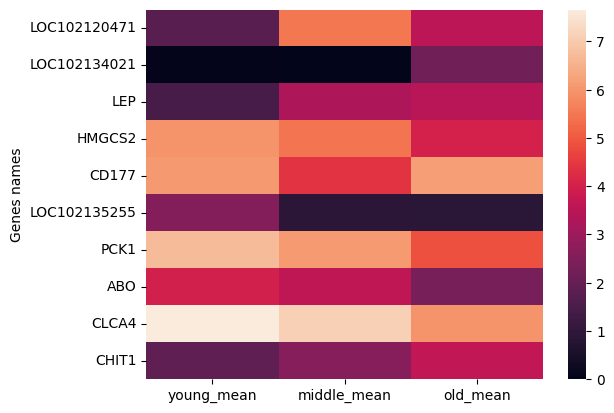

In [31]:
sns.heatmap(summary[['young_mean', 'middle_mean', 'old_mean']].loc[top_genes.index])
plt.show()

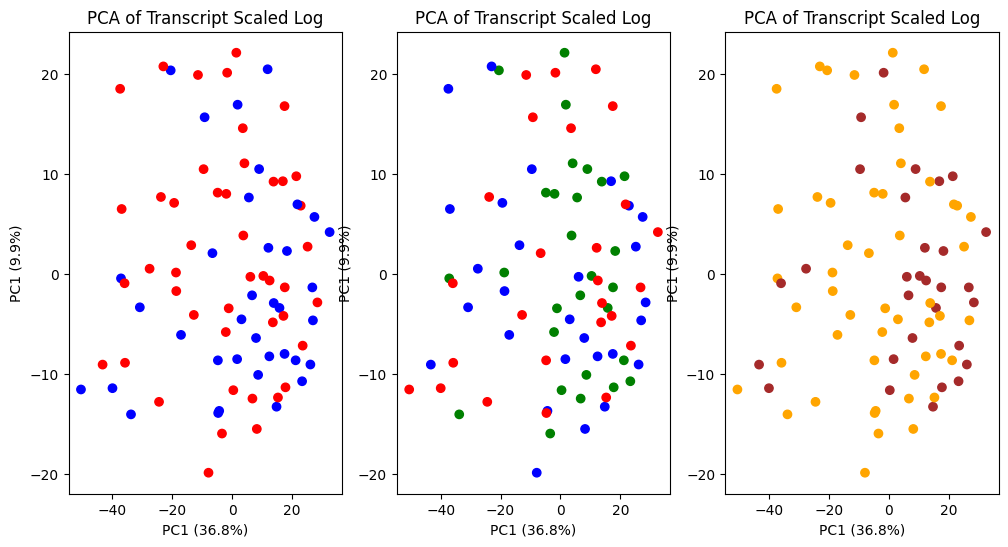

In [32]:

# Begin PCA Analysis
pca = PCA(n_components=2)

transcript_pca = pca.fit_transform(transcript_scaled.T)

gender_map = {'Male':'blue', 'Female':'red'}
colors_gender = metadata.loc[transcript_log.columns, 'Gender'].map(gender_map)

age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_scaled.columns, 'Age'].map(age_map)

region_map = {'Proximal': 'brown', 'Distal':'orange'}
colors_region = metadata.loc[transcript_scaled.columns, 'Region'].map(region_map)

fig, axes = plt.subplots(1,3,figsize=(12,6))

# Plotting First Graph
axes[0].scatter(transcript_pca[:,0],transcript_pca[:,1], c=colors_gender)
axes[0].set_title("PCA of Transcript Scaled Log")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC1 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

#Plotting second graph
axes[1].scatter(transcript_pca[:,0],transcript_pca[:,1], c=colors_age)
axes[1].set_title("PCA of Transcript Scaled Log")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC1 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

axes[2].scatter(transcript_pca[:,0],transcript_pca[:,1], c=colors_region)
axes[2].set_title("PCA of Transcript Scaled Log")
axes[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC1 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

plt.tight_layout
plt.show()

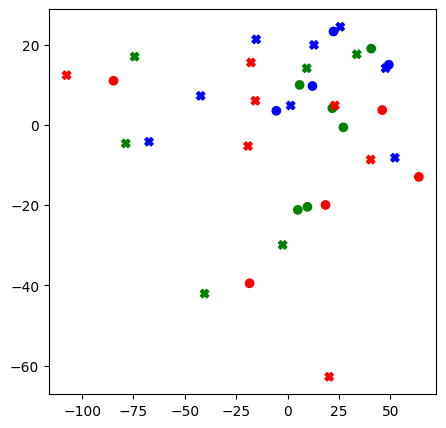

In [33]:
# Time to start computing PCA of subsets to see distinguishing features

male_pca = pca.fit_transform(transcript_male.T)

# Create Color and Region Mapping
age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_male.columns, 'Age'].map(age_map)

# Region categories
regions = metadata['Region'].unique()
markers = {'Proximal':'o', 'Distal':'X'}  # circle for Proximal, X for Distal

plt.figure(figsize=(5,5))

for region in regions:
    idx = metadata.loc[transcript_male.columns, 'Region'] == region
    plt.scatter(male_pca[idx,0], male_pca[idx,1],
                c=colors_age[idx],
                marker=markers[region],
                label=region)
plt.show()

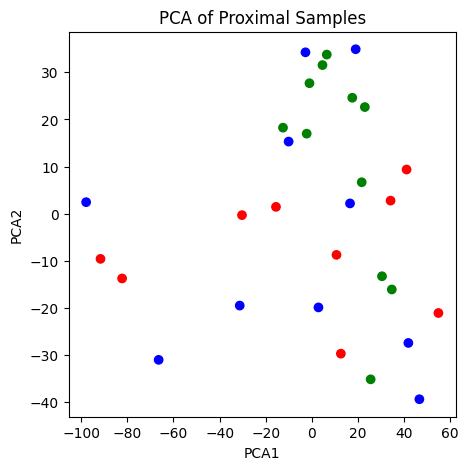

In [34]:
# Proximal PCA

proximal_pca = pca.fit_transform(transcript_proximal.T)

age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_proximal.columns, 'Age'].map(age_map)

plt.figure(figsize=(5,5))
plt.scatter(proximal_pca[:,0],proximal_pca[:,1],c=colors_age)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Proximal Samples")
plt.show()

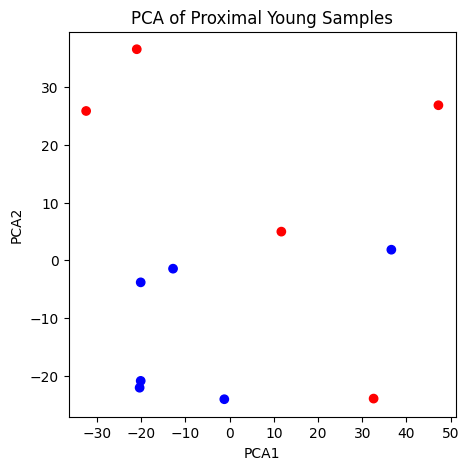

In [35]:
# PCA of Proximal Young
proximal_young_pca = pca.fit_transform(transcript_young_proximal.T)

#age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
#colors_age = metadata.loc[transcript_proximal.columns, 'Age'].map(age_map)

gender_map = {'Male':'blue', 'Female':'red'}
colors_gender = metadata.loc[transcript_young_proximal.columns, 'Gender'].map(gender_map)

plt.figure(figsize=(5,5))
plt.scatter(proximal_young_pca[:,0],proximal_young_pca[:,1],c=colors_gender)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Proximal Young Samples")
plt.show()

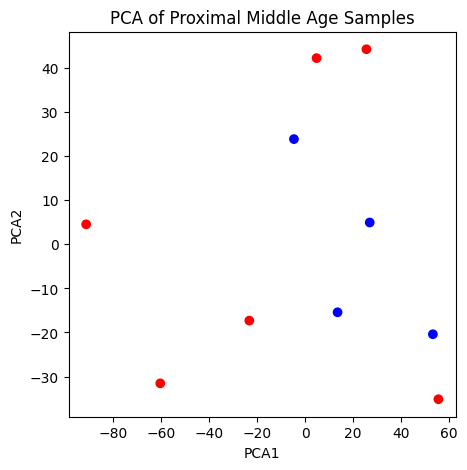

In [36]:
# PCA of Proximal Middle Age
proximal_middle_pca = pca.fit_transform(transcript_middle_proximal.T)

#age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
#colors_age = metadata.loc[transcript_proximal.columns, 'Age'].map(age_map)

gender_map = {'Male':'blue', 'Female':'red'}
colors_gender = metadata.loc[transcript_middle_proximal.columns, 'Gender'].map(gender_map)

plt.figure(figsize=(5,5))
plt.scatter(proximal_middle_pca[:,0],proximal_middle_pca[:,1],c=colors_gender)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Proximal Middle Age Samples")
plt.show()

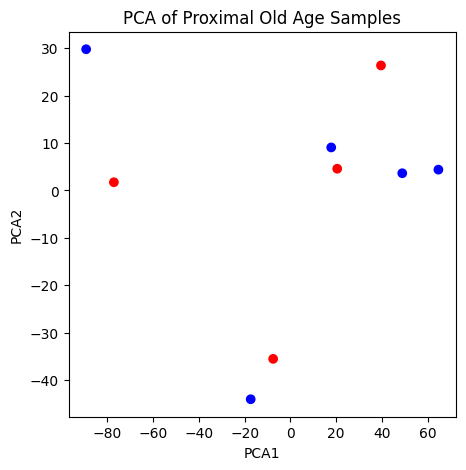

In [37]:
# PCA of Proximal Middle Age
proximal_old_pca = pca.fit_transform(transcript_old_proximal.T)

#age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
#colors_age = metadata.loc[transcript_proximal.columns, 'Age'].map(age_map)

gender_map = {'Male':'blue', 'Female':'red'}
colors_gender = metadata.loc[transcript_old_proximal.columns, 'Gender'].map(gender_map)

plt.figure(figsize=(5,5))
plt.scatter(proximal_old_pca[:,0],proximal_old_pca[:,1],c=colors_gender)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Proximal Old Age Samples")
plt.show()

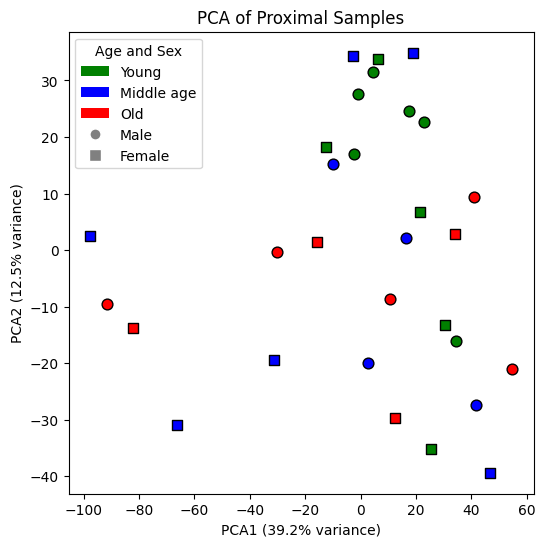

In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# PCA transform
proximal_pca = pca.fit_transform(transcript_proximal.T)

# Map ages to colors
age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_proximal.columns, 'Age'].map(age_map)

# Map sex to markers
marker_map = {'Male': 'o', 'Female': 's'}
markers_sex = metadata.loc[transcript_proximal.columns, 'Gender'].map(marker_map)

# Plot
plt.figure(figsize=(6,6))

for sex in marker_map.keys():
    for age in age_map.keys():
        idx = (metadata.loc[transcript_proximal.columns, 'Gender'] == sex) & \
              (metadata.loc[transcript_proximal.columns, 'Age'] == age)
        plt.scatter(
            proximal_pca[idx,0],
            proximal_pca[idx,1],
            c=age_map[age],
            marker=marker_map[sex],
            edgecolor='k',  # optional: black edge
            s=60,
            label=f"{age}, {sex}"  # temporary label for legend
        )

# Get explained variance ratios
explained_var = pca.explained_variance_ratio_

# Update axis labels with explained variance (as %)
plt.xlabel(f"PCA1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PCA2 ({explained_var[1]*100:.1f}% variance)")


#plt.xlabel("PCA1")
#plt.ylabel("PCA2")
plt.title("PCA of Proximal Samples")

# Create custom legend for Age
age_patches = [Patch(facecolor=color, label=age) for age, color in age_map.items()]

# Create custom legend for Sex
marker_lines = [Line2D([0], [0], marker=marker_map[sex], color='w', markerfacecolor='grey', markersize=8, label=sex) for sex in marker_map.keys()]

# Combine legends
plt.legend(handles=age_patches + marker_lines, title="Age and Sex", loc='upper left')

plt.show()


In [39]:
loadings = pd.DataFrame(
    pca.components_.T,  # rows = genes, columns = PCs
    index=transcript_distal.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Get top 10 genes for each principal component
top_genes_per_pc = {}

for pc in loadings.columns:
    # Sort by absolute value to capture strongest contributors
    top_genes = loadings[pc].abs().sort_values(ascending=False).head(10)
    top_genes_per_pc[pc] = top_genes
    print(f"Top 10 genes for {pc}:")
    print(top_genes)
    print("\n")

Top 10 genes for PC1:
Genes names
CLCA1           0.047251
LOC107131031    0.042656
PCP4            0.040594
ADAMDEC1        0.039094
LOC102141707    0.037571
AGR2            0.037414
ZG16            0.037360
JCHAIN          0.036930
SPINK1          0.036762
ST6GALNAC1      0.036726
Name: PC1, dtype: float64


Top 10 genes for PC2:
Genes names
HMGCS2          0.059760
SLC14A2         0.052199
PCK1            0.049744
CLCA4           0.049385
LOC102141707    0.047540
KRT7            0.046153
LOC107131031    0.045795
TFF1            0.045003
DUOXA2          0.043972
B4GALNT2        0.042128
Name: PC2, dtype: float64




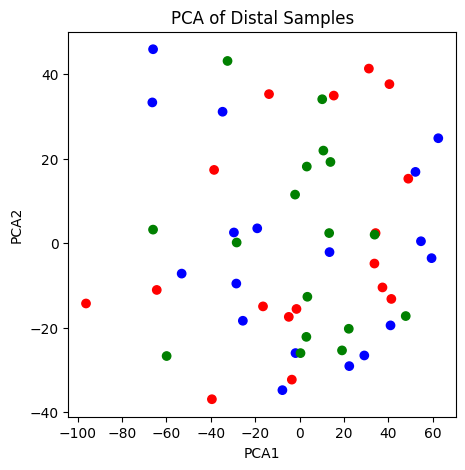

In [40]:
# Distal PCA

distal_pca = pca.fit_transform(transcript_distal.T)

age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_distal.columns, 'Age'].map(age_map)

plt.figure(figsize=(5,5))
plt.scatter(distal_pca[:,0],distal_pca[:,1],c=colors_age)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Distal Samples")
plt.show()

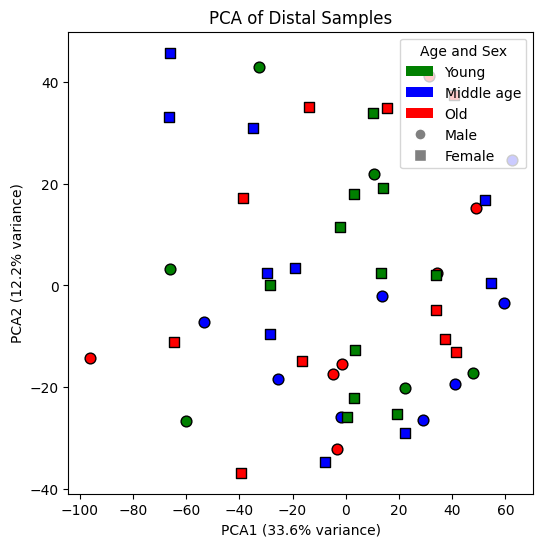

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# PCA transform
distal_pca = pca.fit_transform(transcript_distal.T)

# Map ages to colors
age_map = {'Young': 'green', 'Middle age':'blue', 'Old': 'red'}
colors_age = metadata.loc[transcript_distal.columns, 'Age'].map(age_map)

# Map sex to markers
marker_map = {'Male': 'o', 'Female': 's'}
markers_sex = metadata.loc[transcript_distal.columns, 'Gender'].map(marker_map)

# Plot
plt.figure(figsize=(6,6))

for sex in marker_map.keys():
    for age in age_map.keys():
        idx = (metadata.loc[transcript_distal.columns, 'Gender'] == sex) & \
              (metadata.loc[transcript_distal.columns, 'Age'] == age)
        plt.scatter(
            distal_pca[idx,0],
            distal_pca[idx,1],
            c=age_map[age],
            marker=marker_map[sex],
            label=f"{age}, {sex}",
            edgecolor='k',  # optional: black edge for visibility
            s=60
        )

# Get explained variance ratios
explained_var = pca.explained_variance_ratio_

# Update axis labels with explained variance (as %)
plt.xlabel(f"PCA1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PCA2 ({explained_var[1]*100:.1f}% variance)")

#plt.xlabel("PCA1")
#plt.ylabel("PCA2")
plt.title("PCA of Distal Samples")

# Create custom legends for color (Age) and marker (Sex)
age_patches = [Patch(facecolor=color, label=age) for age, color in age_map.items()]
plt.legend(handles=age_patches, title="Age", loc='upper right')

# Optional: create a separate legend for markers
from matplotlib.lines import Line2D
marker_lines = [Line2D([0], [0], marker=marker_map[sex], color='w', markerfacecolor='grey', markersize=8, label=sex) for sex in marker_map.keys()]
plt.legend(handles=age_patches + marker_lines, title="Age and Sex", loc='upper right')

plt.show()

print()

In [42]:
loadings = pd.DataFrame(
    pca.components_.T,  # rows = genes, columns = PCs
    index=transcript_proximal.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Get top 10 genes for each principal component
top_genes_per_pc = {}

for pc in loadings.columns:
    # Sort by absolute value to capture strongest contributors
    top_genes = loadings[pc].abs().sort_values(ascending=False).head(10)
    top_genes_per_pc[pc] = top_genes
    print(f"Top 10 genes for {pc}:")
    print(top_genes)
    print("\n")

Top 10 genes for PC1:
Genes names
CLCA1           0.051925
TFF3            0.047053
AGR2            0.045654
LOC102120471    0.041931
ADAMDEC1        0.040760
ZG16            0.039031
ACTA1           0.038483
SPINK1          0.038276
ST6GALNAC1      0.038174
GPX2            0.038110
Name: PC1, dtype: float64


Top 10 genes for PC2:
Genes names
CR2             0.055632
CD79B           0.052811
CLCA1           0.050931
LOC102120471    0.050028
LTB             0.049095
MS4A1           0.046399
FDCSP           0.046053
CD19            0.044974
SELL            0.044460
CCR7            0.043892
Name: PC2, dtype: float64




In [43]:
# Computing Differnetial Expressions for Volcano Plot

fold_change = old_mean - young_mean

p_values = transcript_log.apply(lambda x: ttest_ind(x[old_samples], x[young_samples])[1],axis=1)
negative_p_values = -np.log10(p_values+1e-10)



In [44]:
# Computer Differential Expressions for Distal and Proximal Regions
proximal_oy_fc = old_proximal_mean - young_proximal_mean
proximal_om_fc = old_proximal_mean - middle_proximal_mean

distal_oy_fc = old_distal_mean - young_distal_mean
distal_om_fc = old_distal_mean - middle_distal_mean

In [45]:
# Computer P Values accordingly
p_values = []
t_stats = []

for gene in transcript.index:
    t, p = stats.ttest_ind(transcript_old_proximal.loc[gene], transcript_young_proximal.loc[gene], equal_var=False)
    t_stats.append(t)
    p_values.append(p)

results = pd.DataFrame({
    't_stat': t_stats,
    'p_value': p_values
}, index=transcript.index)

In [46]:
import numpy as np
from statsmodels.stats.multitest import multipletests

# Remove NaN p-values
mask_valid = results['p_value'].notna() & np.isfinite(results['p_value'])
valid_p = results.loc[mask_valid, 'p_value']

# Apply FDR correction only on valid values
adj_p = np.full(len(results), np.nan)
adj_p[mask_valid] = multipletests(valid_p, method='fdr_bh')[1]

results['p_adj'] = adj_p
results['log2FC'] = proximal_oy_fc



In [47]:
def label_gene(row):
    if row['p_adj'] < 0.1 and row['log2FC'] > 0.10:   # upregulated threshold
        return 'Upregulated'
    elif row['p_adj'] < 0.1 and row['log2FC'] < -0.10:  # downregulated threshold
        return 'Downregulated'
    else:
        return 'Not significant'

results['Regulation'] = results.apply(label_gene, axis=1)


In [48]:
print(results[['log2FC', 'p_adj']].isna().sum())


log2FC    0
p_adj     1
dtype: int64


In [49]:
results

,t_stat,p_value,p_adj,log2FC,Regulation
Genes names,,,,,
A1CF,-2.083696,0.060048,0.548813,-0.922249,Not significant
A4GALT,0.320821,0.752452,0.959945,0.050925,Not significant
AAAS,0.126418,0.901691,0.985880,0.015031,Not significant
AACS,0.506279,0.620521,0.927653,0.136600,Not significant
AADAT,1.529732,0.150017,0.667759,0.228604,Not significant
...,...,...,...,...,...
ZXDC,-1.069286,0.299421,0.794797,-0.105442,Not significant
ZYG11B,-3.030008,0.010535,0.382186,-0.770430,Not significant
ZYX,0.369134,0.718862,0.950494,0.082735,Not significant


In [50]:
results['Regulation'].value_counts()


Regulation
Not significant    14112
Downregulated          8
Upregulated            1
Name: count, dtype: int64

In [51]:
# Upregulated genes
up_genes = results.index[results['Regulation'] == 'Upregulated']
print("Upregulated genes:")
print(up_genes.tolist())

# Downregulated genes
down_genes = results.index[results['Regulation'] == 'Downregulated']
print("\nDownregulated genes:")
print(down_genes.tolist())



Upregulated genes:
['EXOSC7']

Downregulated genes:
['ABO', 'CIDEA', 'PTPRR', 'SLC14A2', 'SLC6A9', 'TMCC3', 'TNFRSF21', 'XPNPEP2']


TypeError: '<' not supported between instances of 'list' and 'float'

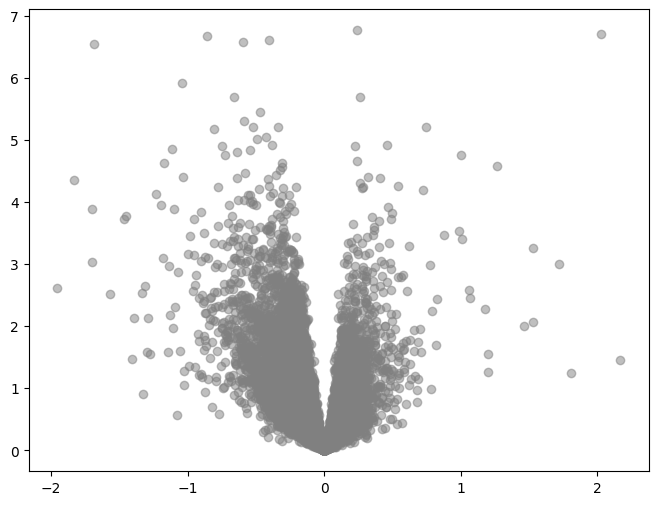

In [52]:
plt.figure(figsize=(8,6))

plt.scatter(fold_change, negative_p_values, c='grey',alpha=0.5)

#Highlight significant genes
sig_threshold = 0.05
fold_change_threshold = 1

#Determining the most up regulated and most down regulated genes
down_sig_genes = (p_values < sig_threshold) & (fold_change < -fold_change_threshold)
up_sig_genes = (p_values < sig_threshold) & (fold_change > fold_change_threshold)

# Top 10 upregulated genes by -log10 p-value
top_up_genes = negative_p_values[up_sig_genes].sort_values(ascending=False).head(10).index

# Top 10 downregulated genes by -log10 p-value
top_down_genes = negative_p_values[down_sig_genes].sort_values(ascending=False).head(10).index

plt.scatter(fold_change[up_sig_genes], negative_p_values[up_sig_genes], c='red',alpha=0.8)
plt.scatter(fold_change[down_sig_genes], negative_p_values[down_sig_genes], c='blue',alpha=0.8)

plt.axhline(-np.log10(sig_threshold), color='blue',linestyle='--')
plt.axvline(fold_change_threshold, color='green',linestyle='--')
plt.axvline(-fold_change_threshold, color='green', linestyle='--')

plt.xlabel('Log2 Fold Change (Old vs Young)')
plt.ylabel('-Log10(p-value)')
plt.title('Volcano Plot of Differential Expression')

for gene in top_up_genes.union(top_down_genes):
    plt.text(fold_change[gene], negative_p_values[gene], gene,
             fontsize=8, ha='right' if fold_change[gene] < 0 else 'left')

plt.show()

In [ ]:
top_up_genes

NameError: name 'top_up_genes' is not defined

In [ ]:
top_down_genes

NameError: name 'top_down_genes' is not defined

/var/folders/l9/7q155c0s6lz9bgv0b52p3qv40000gn/T/ipykernel_35361/1973810072.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, col_idx], x='Gender', y=gene, data=expr_with_meta, palette='coolwarm')
/var/folders/l9/7q155c0s6lz9bgv0b52p3qv40000gn/T/ipykernel_35361/1973810072.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1, col_idx], x='Age', y=gene, data=expr_with_meta, palette='viridis')
/var/folders/l9/7q155c0s6lz9bgv0b52p3qv40000gn/T/ipykernel_35361/1973810072.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(

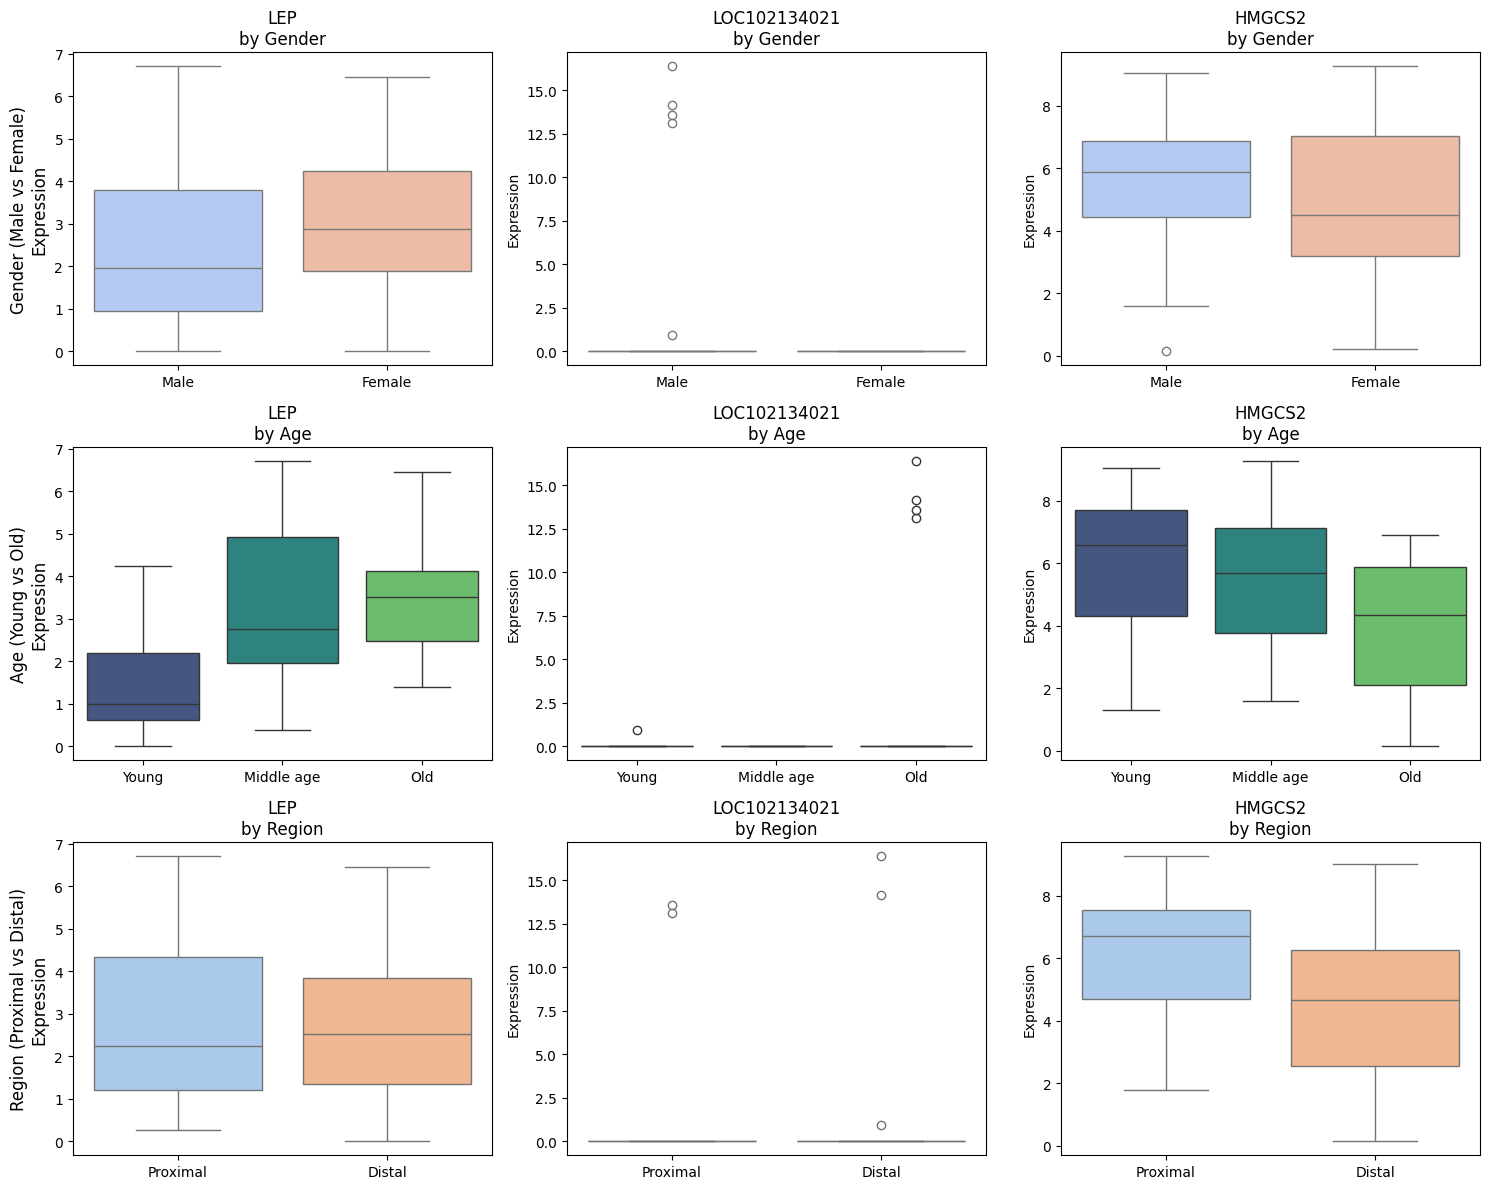

In [ ]:

# --- Example setup ---
# transcript_log: expression dataframe (rows=genes, cols=samples)
# metadata: sample info dataframe (index=sample IDs)

# Example: select your top 5 genes from your analysis
top_genes = list(top_up_genes[:3]) + list(top_down_genes[:2])  # adjust as needed

# Combine expression and metadata
expr_with_meta = transcript_log.T.join(metadata)

# Create figure
fig, axes = plt.subplots(3, len(top_genes), figsize=(5 * len(top_genes), 12))
comparison_titles = ['Gender (Male vs Female)', 'Age (Young vs Old)', 'Region (Proximal vs Distal)']

# Loop through genes and comparisons
for col_idx, gene in enumerate(top_genes):
    # Row 1: Gender
    sns.boxplot(ax=axes[0, col_idx], x='Gender', y=gene, data=expr_with_meta, palette='coolwarm')
    axes[0, col_idx].set_title(f'{gene}\nby Gender')
    axes[0, col_idx].set_xlabel('')
    axes[0, col_idx].set_ylabel('Expression')

    # Row 2: Age
    sns.boxplot(ax=axes[1, col_idx], x='Age', y=gene, data=expr_with_meta, palette='viridis')
    axes[1, col_idx].set_title(f'{gene}\nby Age')
    axes[1, col_idx].set_xlabel('')
    axes[1, col_idx].set_ylabel('Expression')

    # Row 3: Region
    sns.boxplot(ax=axes[2, col_idx], x='Region', y=gene, data=expr_with_meta, palette='pastel')
    axes[2, col_idx].set_title(f'{gene}\nby Region')
    axes[2, col_idx].set_xlabel('')
    axes[2, col_idx].set_ylabel('Expression')

# Add overall titles
for i in range(3):
    axes[i, 0].set_ylabel(f'{comparison_titles[i]}\nExpression', fontsize=12)

# Improve spacing
plt.tight_layout()
plt.show()


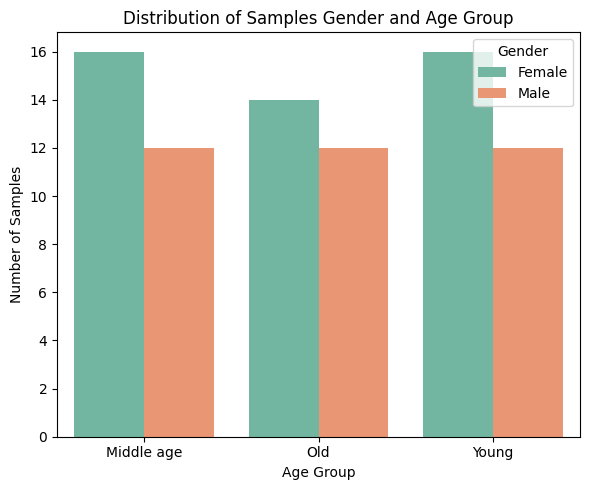

In [ ]:
metadata.groupby(['Age', 'Gender']).size().unstack(fill_value=0)

sample_counts = metadata.groupby(['Age', 'Gender']).size().reset_index(name='Count')

plt.figure(figsize=(6,5))
sns.barplot(data=sample_counts, x='Age', y='Count', hue='Gender', palette='Set2')
plt.title('Distribution of Samples Gender and Age Group')
plt.ylabel('Number of Samples')
plt.xlabel('Age Group')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [ ]:
sample_counts

,Age,Gender,Count
0,Middle age,Female,16
1,Middle age,Male,12
2,Old,Female,14
3,Old,Male,12
4,Young,Female,16
5,Young,Male,12


In [ ]:
top10_proximal_genes = proximal_var.sort_values(ascending=False).head(10).index
print(top10_proximal_genes)

top10_distal_genes = distal_var.sort_values(ascending=False).head(10).index
print(top10_distal_genes)

Index(['LOC102120471', 'LOC102134021', 'LOC102120947', 'LOC102139757',
       'LOC107131031', 'LOC102141707', 'LOC102116757', 'CLCA1', 'LOC102120083',
       'FDCSP'],
      dtype='object', name='Genes names')
Index(['LOC102120471', 'AQP8', 'LOC102134021', 'LOC102139757', 'LOC102120083',
       'LOC102120947', 'CLCA1', 'CD177', 'LOC107130237', 'FDCSP'],
      dtype='object', name='Genes names')


In [ ]:
prox_data = transcript_proximal.loc[top10_proximal_genes].melt(ignore_index=False, var_name='Sample', value_name='Expression')
prox_data['Area'] = 'Proximal'
prox_data.reset_index(inplace=True)
prox_data.rename(columns={'index': 'Gene'}, inplace=True)

# Distal data
dist_data = transcript_distal.loc[top10_distal_genes].melt(ignore_index=False, var_name='Sample', value_name='Expression')
dist_data['Area'] = 'Distal'
dist_data.reset_index(inplace=True)
dist_data.rename(columns={'index': 'Gene'}, inplace=True)

# Combine
combined_df = pd.concat([prox_data, dist_data])

In [ ]:
combined_df

,Genes names,Sample,Expression,Area
0,LOC102120471,2-22-A,1.547455,Proximal
1,LOC102134021,2-22-A,0.000000,Proximal
2,LOC102120947,2-22-A,0.000000,Proximal
3,LOC102139757,2-22-A,6.060896,Proximal
4,LOC107131031,2-22-A,5.437151,Proximal
...,...,...,...,...
515,LOC102120947,2-8-R,7.462725,Distal
516,CLCA1,2-8-R,2.436050,Distal
517,CD177,2-8-R,3.529948,Distal
518,LOC107130237,2-8-R,5.487054,Distal


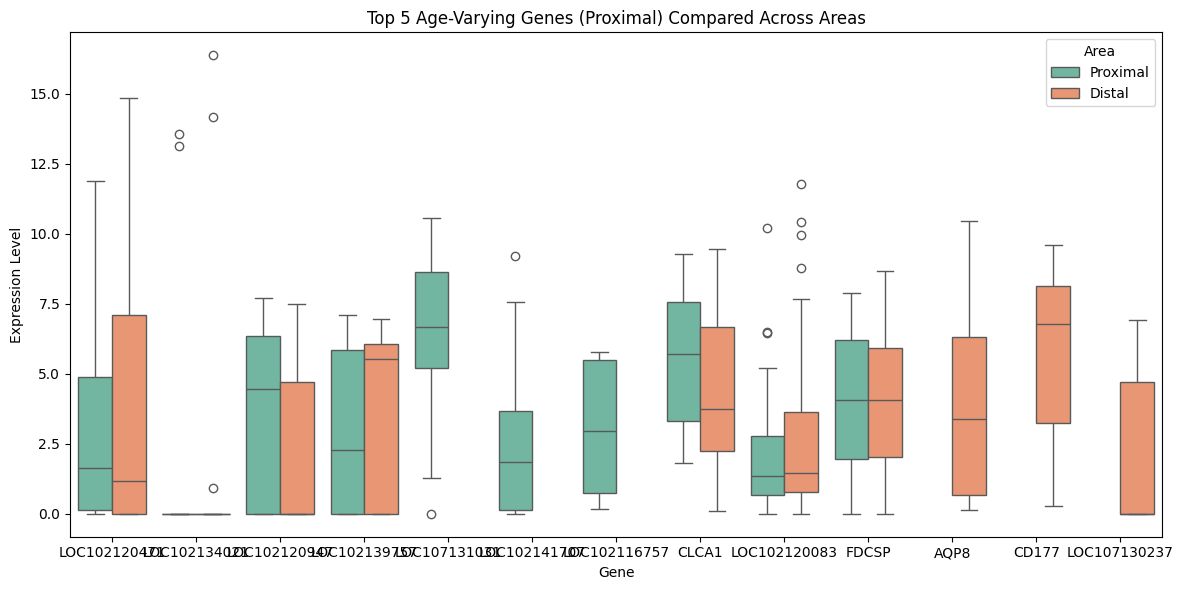

In [ ]:
plt.figure(figsize=(12, 6))  # slightly wider for 5 genes
sns.boxplot(
    data=combined_df,
    x='Genes names',
    y='Expression',
    hue='Area',
    palette='Set2'
)

plt.title('Top 5 Age-Varying Genes (Proximal) Compared Across Areas')
plt.xlabel('Gene')
plt.ylabel('Expression Level')
plt.legend(title='Area')
plt.tight_layout()
plt.show()



In [ ]:
young_mean

In [ ]:
common_genes = transcript.index.intersection(proteins.index)
transcript_common = transcript.loc[common_genes]
proteins_common = proteins.loc[common_genes]

# Get correlation across samples for each gene
gene_corr = transcript_common.corrwith(proteins_common, axis=1,method='pearson')

In [ ]:
gene_corr.median()

np.float64(0.1015829253145194)

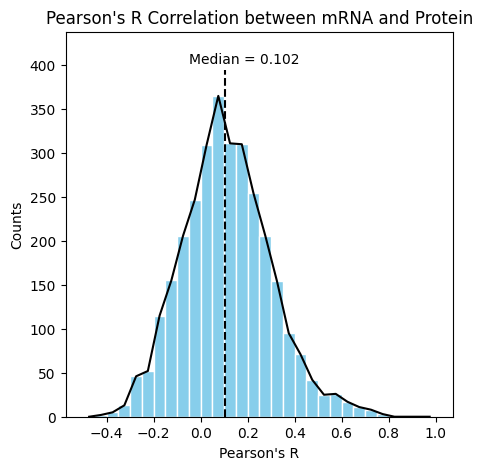

In [ ]:
plt.figure(figsize=(5,5))

bins = np.arange(-0.5, 1 + 0.05, 0.05)  # +0.05 to include the last edge

# Plot histogram with outlined bins
counts, bin_edges, patches = plt.hist(gene_corr, bins=bins, edgecolor='white', color='skyblue')

# Compute bin centers for line overlay
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.plot(bin_centers, counts, color='black', linestyle='-')

gene_median = gene_corr.median()
plt.axvline(x=gene_median,color='black',linestyle='--', label=f'Median {gene_median:.3f}',ymax=0.9)
plt.text(gene_median/2 - 0.1, max(counts)*1.1, f'Median = {gene_median:.3f}', color='Black')
plt.title("Pearson's R Correlation between mRNA and Protein")
plt.xlabel("Pearson's R")
plt.ylabel("Counts")

plt.ylim(0, max(counts) * 1.2)

plt.show()

In [ ]:
# Option 1: give the column a name
corr_df = gene_corr.rename('r').to_frame()

merged_df = pathway_exploded.merge(corr_df, left_on='Genes', right_index=True)
merged_df.head()

,Pathway ID,Pathway name,Displayed in Extended Data Fig. 4a,Count,p value,Fold Enrichment,FDR,Genes,Sex,Region,r
2,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,KDM3B,male,Proximal,-0.092856
11,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,IWS1,male,Proximal,0.190707
13,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,BTAF1,male,Proximal,-0.166502
30,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,HUWE1,male,Proximal,0.099113
33,GO:0006338,chromatin remodeling,yes,40,0.0,3.964468,0.0,BAZ1B,male,Proximal,-0.045484


In [ ]:
metadata_df = pd.DataFrame.from_dict(sample_to_info, orient='index')
metadata_df.index.name = 'SampleID'
metadata_df.reset_index(inplace=False)  # optional
metadata_df.head()


,Age,Gender,Region,Location
SampleID,,,,
2-22-A,Middle age,Female,Proximal,Ascending colon
2-22-D,Middle age,Female,Distal,Descending colon
2-22-R,Middle age,Female,Distal,Rectum
2-22-T,Middle age,Female,Proximal,Transverse colon
2-25-A,Middle age,Female,Proximal,Ascending colon


In [ ]:
proteins

1,2-29-A,2-7-A,2-8-A,2-16-A,2-18-A,2-20-A,2-23-A,2-29-T,2-8-T,2-16-T,...,2-30-R,3-25-R,2-7-T,3-19-A,3-7-A,2-29-D,3-15-D,3-15-T,3-18-D,3-19-D
Gene names,,,,,,,,,,,,,,,,,,,,,
GSTP1,0.947451,1.160542,1.084707,0.985390,0.875839,0.837299,0.794411,0.955362,1.060946,0.846684,...,0.789786,0.651540,0.898998,0.838027,1.145696,0.795706,1.051965,0.932046,0.773629,0.833231
GAPDH,0.927883,1.284003,0.964951,1.118563,0.971331,0.910677,1.045518,1.035092,1.224453,1.081631,...,1.097350,3.702514,1.126977,1.174646,1.550338,1.595955,1.183228,1.131521,1.202691,0.945105
OAS1,0.883592,0.820048,1.583599,0.580530,1.093860,1.372942,1.461154,0.722997,1.395069,0.790776,...,0.711842,1.323365,0.817531,0.867034,0.420517,0.086007,0.980983,1.131720,0.948612,1.103268
CES1,1.468547,1.506702,1.640234,0.943155,0.911634,1.487612,0.936032,1.209600,1.576961,1.069153,...,0.485954,0.504485,1.228234,0.865431,0.525230,0.329712,1.797434,2.379647,0.606275,1.377644
PDCD6,1.683050,1.373192,1.006688,1.011671,1.072028,0.918124,1.080083,1.704611,1.120459,1.220846,...,1.153488,0.917397,1.153763,1.480637,0.990853,1.533412,1.169462,1.020476,1.132429,1.524681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TANGO2,0.858542,1.183900,0.999958,0.937866,0.992129,0.859369,0.866797,0.879621,1.160718,0.963463,...,0.992491,0.737889,1.104054,0.913428,0.837250,0.883063,0.855609,0.756773,0.716689,0.922293
TAMM41,0.936670,0.865762,1.516996,1.040369,1.324212,1.372732,1.106263,0.887945,1.073248,0.856725,...,0.911933,0.976623,1.034377,0.805510,0.759976,0.496169,1.062141,0.991801,0.587168,1.089838
IGHG1,0.856162,1.499562,1.089590,2.065222,0.855087,0.655113,0.718587,0.947170,1.053603,1.524258,...,0.452966,0.388537,1.098382,2.912636,1.771690,1.317356,1.219071,1.232026,1.738107,2.926823


In [ ]:
gene_corr.nlargest(10)

HMGCS2    0.792793
DDX60     0.759269
ACSF2     0.753821
STAT1     0.741076
CD177     0.738672
PCK1      0.730593
ETFDH     0.729066
ACADM     0.721249
HPGD      0.718864
CPT1A     0.714580
dtype: float64

In [ ]:
genes_of_interest = corr_df.index.tolist()
genes_of_interest

['A1CF',
 'AAAS',
 'AACS',
 'AAK1',
 'AAMDC',
 'AAMP',
 'AARS',
 'AARS2',
 'AARSD1',
 'AASDHPPT',
 'AASS',
 'ABAT',
 'ABCA8',
 'ABCB1',
 'ABCB10',
 'ABCB6',
 'ABCB8',
 'ABCC1',
 'ABCC3',
 'ABCC4',
 'ABCF1',
 'ABCF3',
 'ABHD10',
 'ABHD11',
 'ABHD12',
 'ABHD16A',
 'ABI1',
 'ABI3BP',
 'ABLIM1',
 'ABR',
 'ACAA2',
 'ACACA',
 'ACACB',
 'ACAD10',
 'ACAD8',
 'ACAD9',
 'ACADM',
 'ACADS',
 'ACADSB',
 'ACAP1',
 'ACAP2',
 'ACAT1',
 'ACBD3',
 'ACBD5',
 'ACIN1',
 'ACLY',
 'ACO1',
 'ACO2',
 'ACOT11',
 'ACOT13',
 'ACOT2',
 'ACOT7',
 'ACOT9',
 'ACOX2',
 'ACOX3',
 'ACP1',
 'ACP5',
 'ACP6',
 'ACSF2',
 'ACSL1',
 'ACSL3',
 'ACSL4',
 'ACSS1',
 'ACSS2',
 'ACSS3',
 'ACTG2',
 'ACTN1',
 'ACTN1',
 'ACTN3',
 'ACTN4',
 'ACTR10',
 'ACTR1B',
 'ACTR1B',
 'ACYP1',
 'ADA',
 'ADAM10',
 'ADAM17',
 'ADAMDEC1',
 'ADAR',
 'ADD1',
 'ADD3',
 'ADGRE5',
 'ADH7',
 'ADIRF',
 'ADK',
 'ADO',
 'ADPRH',
 'ADPRHL2',
 'ADRM1',
 'ADSL',
 'ADSS',
 'AFG3L2',
 'AGK',
 'AGL',
 'AGO2',
 'AGO3',
 'AGPAT3',
 'AGPS',
 'AGR2',
 'AGR3',
 'AHCTF1'

In [ ]:
from bioservices import KEGG

#k = KEGG()
#k.organism = "mfa"  # Macaca fascicularis

#for gene in genes_of_interest:
#    try:
#        pathways = k.get_pathway_by_gene(gene, "mfa")
#        print(f"{gene}: {pathways}")
#    except:
#        print(f"{gene}: no pathways found")

WARNING [bioservices.KEGG:596]:  status is not ok with Not Found
WARNING [bioservices.KEGG:1181]:  Could not parse the entry correctly.


A1CF: None


WARNING [bioservices.KEGG:596]:  status is not ok with Not Found
WARNING [bioservices.KEGG:1181]:  Could not parse the entry correctly.


AAAS: None


WARNING [bioservices.KEGG:596]:  status is not ok with Not Found
WARNING [bioservices.KEGG:1181]:  Could not parse the entry correctly.


...

ARHGEF17: None


WARNING [bioservices.KEGG:596]:  status is not ok with Not Found
WARNING [bioservices.KEGG:1181]:  Could not parse the entry correctly.


ARHGEF2: None


WARNING [bioservices.KEGG:596]:  status is not ok with Not Found
WARNING [bioservices.KEGG:1181]:  Could not parse the entry correctly.


ARHGEF6: None


In [ ]:
sample_to_info


{'2-22-A': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Proximal',
  'Location': 'Ascending colon'},
 '2-22-D': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Distal',
  'Location': 'Descending colon'},
 '2-22-R': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Distal',
  'Location': 'Rectum'},
 '2-22-T': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Proximal',
  'Location': 'Transverse colon'},
 '2-25-A': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Proximal',
  'Location': 'Ascending colon'},
 '2-25-D': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Distal',
  'Location': 'Descending colon'},
 '2-25-R': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Distal',
  'Location': 'Rectum'},
 '2-25-T': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Distal',
  'Location': 'Transverse colon'},
 '3-28-A': {'Age': 'Middle age',
  'Gender': 'Female',
  'Region': 'Proximal',
  'Location': 'Ascending colon'},
 '3-28-

In [67]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from bioservices import KEGG
import time

common_samples = transcript.columns.intersection(proteins.columns)
transcript_aligned = transcript[common_samples]
proteome_aligned = proteins[common_samples]

# ----------------------------
# 4️⃣ Compute gene-wise Pearson correlations
# ----------------------------
def compute_correlations(transcript, protein):
    correlations = {}
    
    # Remove duplicated gene rows if any
    transcript = transcript[~transcript.index.duplicated(keep='first')]
    protein = protein[~protein.index.duplicated(keep='first')]
    
    # Align samples (columns)
    common_samples = transcript.columns.intersection(protein.columns)
    transcript = transcript[common_samples]
    protein = protein[common_samples]
    
    # Only use genes present in both datasets
    common_genes = transcript.index.intersection(protein.index)
    
    for gene in common_genes:
        # Select row as 1D array
        x = transcript.loc[gene].to_numpy().flatten()
        y = protein.loc[gene].to_numpy().flatten()
        
        # Filter positions with NaN
        mask = (~np.isnan(x)) & (~np.isnan(y))
        x_clean = x[mask]
        y_clean = y[mask]
        
        # Only compute if at least 2 paired values
        if len(x_clean) < 2:
            continue
        
        r, _ = pearsonr(x_clean, y_clean)
        correlations[gene] = r
    
    return pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])




corr_df = compute_correlations(transcript_aligned, proteome_aligned)

# Add UniProt IDs for KEGG mapping
gene_to_uniprot = {v: k for k, v in uniprot_to_gene.items()}
corr_df['UniprotID'] = [gene_to_uniprot.get(gene, None) for gene in corr_df.index]

# ----------------------------
# 5️⃣ Initialize KEGG service
# ----------------------------
k = KEGG()
k.organism = "mfa"  # Macaca fascicularis

# ----------------------------
# 6️⃣ Map UniProt IDs to KEGG gene IDs and retrieve pathways
# ----------------------------
gene_pathway_mapping = []

for _, row in corr_df.iterrows():
    up_id = row['UniprotID']
    corr = row['Correlation']
    
    if up_id is None:
        gene_pathway_mapping.append({
            'Gene': row.name,
            'UniProtID': None,
            'KEGG_ID': None,
            'KEGG_Pathway': None,
            'Correlation': corr
        })
        continue

    try:
        # Convert UniProt ID to KEGG gene ID
        conv = k.conv('mfa', f'up:{up_id}')

        kegg_id = None
        if isinstance(conv, dict) and conv:
            kegg_id = list(conv.values())[0]  # safe

        else:
            kegg_id = None

        # Retrieve KEGG pathways
        if kegg_id:
            pathways = k.get_pathway_by_gene(kegg_id, 'mfa')
            if pathways:
                for pid, pname in pathways.items():
                    gene_pathway_mapping.append({
                        'Gene': row.name,
                        'UniProtID': up_id,
                        'KEGG_ID': kegg_id,
                        'KEGG_Pathway': pname,
                        'Correlation': corr
                    })
            else:
                gene_pathway_mapping.append({
                    'Gene': row.name,
                    'UniProtID': up_id,
                    'KEGG_ID': kegg_id,
                    'KEGG_Pathway': None,
                    'Correlation': corr
                })
        else:
            gene_pathway_mapping.append({
                'Gene': row.name,
                'UniProtID': up_id,
                'KEGG_ID': None,
                'KEGG_Pathway': None,
                'Correlation': corr
            })
    except Exception as e:
        print(f"Error mapping {up_id}: {e}")
        gene_pathway_mapping.append({
            'Gene': row.name,
            'UniProtID': up_id,
            'KEGG_ID': None,
            'KEGG_Pathway': None,
            'Correlation': corr
        })
    
    time.sleep(0.1)  # avoid API throttling

# ----------------------------
# 7️⃣ Create final KEGG-correlation DataFrame
# ----------------------------
kegg_corr_df = pd.DataFrame(gene_pathway_mapping)

# Sort by correlation
kegg_corr_df_sorted = kegg_corr_df.sort_values('Correlation', ascending=False)

# ----------------------------
# 8️⃣ Inspect top 20
# ----------------------------
print(kegg_corr_df_sorted.head(20))

KeyboardInterrupt: 